In [1]:
## Load libraries
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.datasets import  mnist
plt.style.use('dark_background')
%matplotlib inline

In [2]:
np.set_printoptions(precision=2)
import tensorflow as tf
tf.__version__

'2.14.0'

In [3]:
#Load MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.transpose(1, 2, 0)
X_test = X_test.transpose(1, 2, 0)
X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])


In [4]:
num_labels = len(np.unique(y_train))
num_features = X_train.shape[0]
num_samples = X_train.shape[1]

In [5]:
#One hot encode class labels
Y_train = tf.keras.utils.to_categorical(y_train).T
Y_test = tf.keras.utils.to_categorical(y_test).T


In [6]:
#Normalizze the samples (images)
xmax = np.amax(X_train)
xmin = np.amin(X_train)
X_train = (X_train - xmin)/(xmax - xmin) #all train features turn into a number between 1 and 0
X_test = (X_test - xmin)/(xmax - xmin) 

In [7]:
print('MNIST set')
print('----------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))
print('Number of output classes = %d'%(num_labels))

MNIST set
----------
Number of training samples = 60000
Number of features = 784
Number of output classes = 10


In [8]:
class Layer:
  def __init__(self):
    self.input = None
    self.output = None

  def forward(self, input):
    pass

  def backward(self, output_gradient, learning_rate):
    pass

In [19]:
## Define the loss function and its gradient
def cce(Y, Yhat):
  return(np.mean(np.sum(-Y*np.log(Yhat), axis=0)))

def cce_gradient(Y, Yhat):
  return(-Y/Yhat)

# TensorFlow in-built function for categorical crossentropy loss
#cce = tf.keras.losses.CategoricalCrossentropy()

In [28]:
class Softmax(Layer):
    def forward(self, input):
        self.input = input  # Assign the input to self.input
        # Ensure that input is a NumPy array before applying softmax
        input_np = np.array(input)
        self.output = tf.nn.softmax(input_np, axis=0).numpy()

    def backward(self, output_gradient, learning_rate=None):
        # Following is the inefficient way of calculating the backward gradient
        softmax_gradient = np.empty((self.input.shape[0], output_gradient.shape[1]), dtype=np.float64)
        for b in range(softmax_gradient.shape[1]):
            softmax_gradient[:, b] = np.dot((np.identity(self.output.shape[0]) - self.output[:, b].T) * self.output[:, b],
                                            output_gradient[:, b])
        return softmax_gradient


In [35]:
## Dense layer class
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = 0.01 * np.random.randn(output_size, input_size + 1) # +1 for bias trick
        self.weights[:, -1] = 0.01 # Set all bias values to the same nonzero constant

    def forward(self, input):
        self.input = np.vstack([input, np.ones((1, input.shape[1]))]) #bias trick
        self.output= np.dot(self.weights, self.input)

def backward(self, output_gradient, learning_rate=None):
        dense_gradient = np.zeros((self.output.shape[0], self.input.shape[1]), dtype=np.float64)
        for b in range(output_gradient.shape[1]):
            dense_gradient += np.dot(output_gradient[:, b].reshape(-1, 1), self.input[:, b].reshape(1, -1))

        dense_gradient = (1 / output_gradient.shape[1]) * dense_gradient
        self.weights -= learning_rate * dense_gradient
        return np.dot(self.weights.T, output_gradient)

        ## Following is the efficient way of calculating the backward gradient
        #dense_gradient = (1/output_gradient.shape[1])1])*np.dot(np.atleast_2d(output_gradient), np.atleast_2d(self.input).T)
        #self.weights = learning_rate * (-dense_gradient)

In [36]:
#Function to generate sample indices for batch processing according to batch size
def generate_batch_indices(num_samples, batch_size):
    #reorder sample indices
    reordered_sample_indices= np.random.choice(num_samples, num_samples, replace=False)
    #Generate batch indices for batch processing
    batch_indices = np.split(reordered_sample_indices, np.arange(batch_size, len(reordered_sample_indices), batch_size))
    return batch_indices

In [37]:
#Example generation of batch indices
batch_size = 100
batch_indices = generate_batch_indices(num_samples, batch_size)
print(batch_indices)

[array([15077, 54973,  2789, 18392, 29602, 56980, 58536, 41169, 29418,
       40279,  4243, 31455, 11469, 16798, 37856,   966, 42135,  5799,
       26323, 55326, 11711, 34043, 22158,  6585, 43908, 24616, 25763,
        3771, 53168,  9527, 20208, 37735, 56562, 41839,  7957, 35198,
       33618, 50812, 41366, 39565, 12623,  5905, 59717, 21418, 54500,
       25138, 39449, 50552, 54275, 10904, 27635, 53530, 19174, 55953,
       32322, 28130,  5946, 42480, 45042,  1692,  9649, 17331, 15053,
       13029, 23286, 31968, 27852, 20820, 43360, 25440, 52329, 29880,
       18395, 43314, 43867, 33455, 36941, 21798, 35053, 29741,    74,
        9108, 48190, 38843, 28001, 33974, 30562, 54821, 30683,  7659,
       36543, 57470, 12266, 44929, 26903, 36053, 37665, 28501, 39695,
       38144]), array([56743, 34880, 32265, 59966, 20568, 51945, 48993, 47598, 43116,
        2834, 41374, 18007, 22295, 29597, 32267, 25333, 35937,   598,
       37261, 30837, 19770,  8209, 54652, 10277, 26986, 23459, 44955,
   

In [38]:
#Train the 0-layer neural network using batch training with batch size = 16
learning_rate = 0.1
batch_size = 16
nepochs = 100
loss_epoch = np.empty(nepochs,dtype=np.float64) #create empty array to store loss values for each epoch


In [39]:
#Neural network architecture
dlayer = Dense(num_features, num_labels)
softmax = Softmax()

In [40]:
epoch = 0
while epoch < nepochs:
    batch_indices = generate_batch_indices(num_samples, batch_size)
    loss = 0
    for b in range(len(batch_indices)):
        dlayer.forward(X_train[:, batch_indices[b]])
        softmax.forward(dlayer.output)
        loss += cce(Y_train[:, batch_indices[b]], softmax.output)

        # backward prop starts here
        grad = cce_gradient(Y_train[:, batch_indices[b]], softmax.output)
        grad = softmax.backward(grad)
        grad = dlayer.backward(grad, learning_rate)

    loss_epoch[epoch] = loss/len(batch_indices)
    print('Epoch %d: loss = %f'%(epoch+1, loss_epoch[epoch]))
    epoch = epoch + 1


Epoch 1: loss = 2.308400
Epoch 2: loss = 2.308400
Epoch 3: loss = 2.308400
Epoch 4: loss = 2.308400
Epoch 5: loss = 2.308400
Epoch 6: loss = 2.308400
Epoch 7: loss = 2.308400
Epoch 8: loss = 2.308400
Epoch 9: loss = 2.308400
Epoch 10: loss = 2.308400
Epoch 11: loss = 2.308400
Epoch 12: loss = 2.308400
Epoch 13: loss = 2.308400
Epoch 14: loss = 2.308400
Epoch 15: loss = 2.308400
Epoch 16: loss = 2.308400
Epoch 17: loss = 2.308400
Epoch 18: loss = 2.308400
Epoch 19: loss = 2.308400
Epoch 20: loss = 2.308400
Epoch 21: loss = 2.308400
Epoch 22: loss = 2.308400
Epoch 23: loss = 2.308400
Epoch 24: loss = 2.308400
Epoch 25: loss = 2.308400
Epoch 26: loss = 2.308400
Epoch 27: loss = 2.308400
Epoch 28: loss = 2.308400
Epoch 29: loss = 2.308400
Epoch 30: loss = 2.308400
Epoch 31: loss = 2.308400
Epoch 32: loss = 2.308400
Epoch 33: loss = 2.308400
Epoch 34: loss = 2.308400
Epoch 35: loss = 2.308400
Epoch 36: loss = 2.308400
Epoch 37: loss = 2.308400
Epoch 38: loss = 2.308400
Epoch 39: loss = 2.30

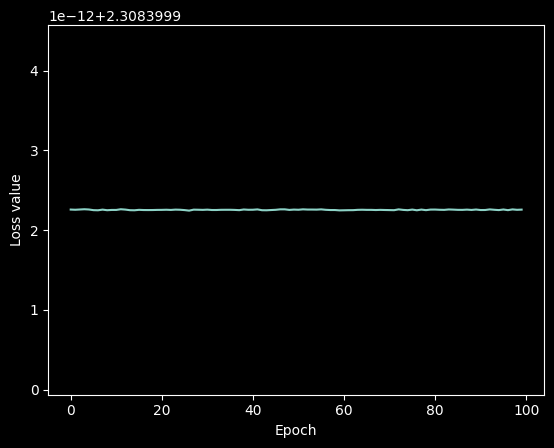

In [43]:
##Plot training loss as a function of epoch
plt.plot(loss_epoch)
plt.xlabel('Epoch')
plt.ylabel('Loss value')
plt.show()

In [45]:
#Accuracy on test set
dlayer.forward(X_test)
softmax.forward(dlayer.output)
ypred = np.argmax(softmax.output.T, axis=1)
print(ypred)
ytrue = np.argmax(Y_test.T, axis=1)
print(ytrue)
np.mean(ytrue==ypred)

[8 8 6 ... 1 7 9]
[7 2 1 ... 4 5 6]


0.0844